In [4]:
import pandas as pd
import seaborn as sns
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

df = df[['total_bill','tip','sex','smoker','size']]
df = df.dropna()


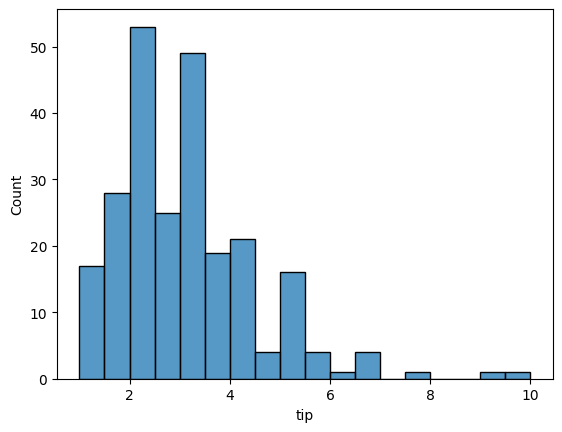

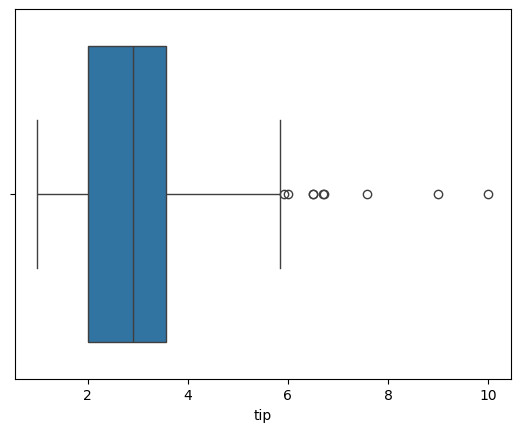

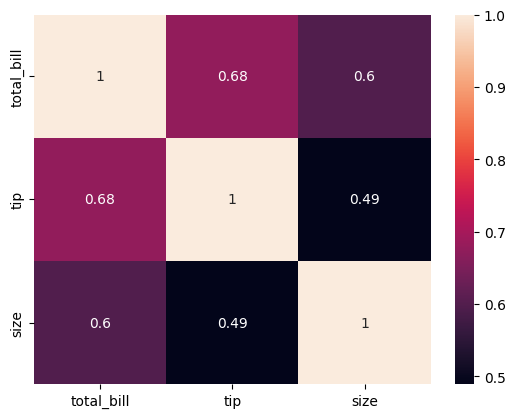

In [5]:
sns.histplot(df["tip"].dropna())
plt.show()

sns.boxplot(x=df["tip"])
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [6]:
df = df[['total_bill','tip','sex','smoker','size']]
df = df.dropna()

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("smoker", axis=1)
y = df["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [9]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.6530612244897959


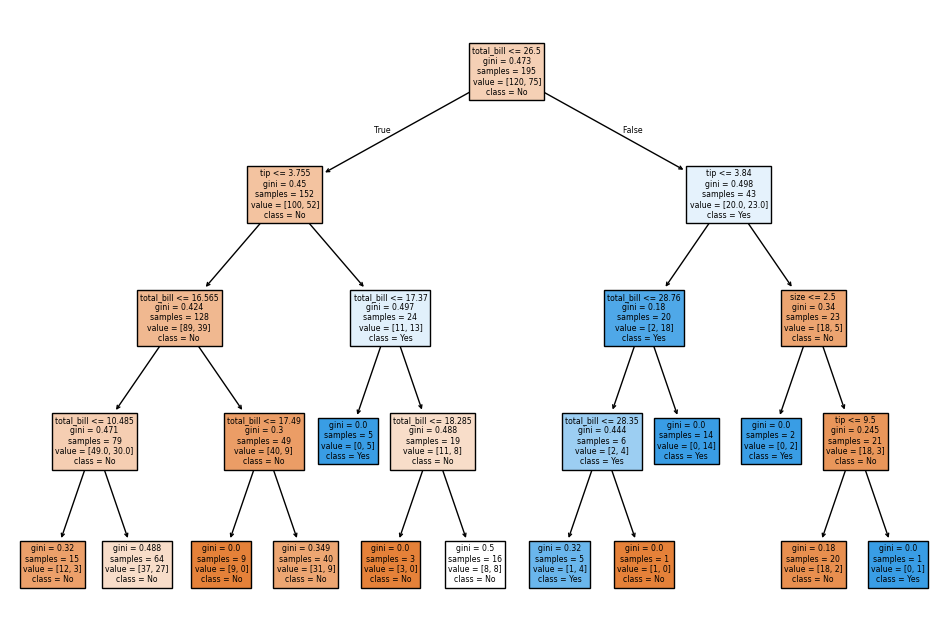

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True
)

plt.show()


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [13]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.6122448979591837


In [14]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

print(importance.sort_values(by="Importance", ascending=False))

      Feature  Importance
0  total_bill    0.513487
1         tip    0.371880
3        size    0.079515
2         sex    0.035118


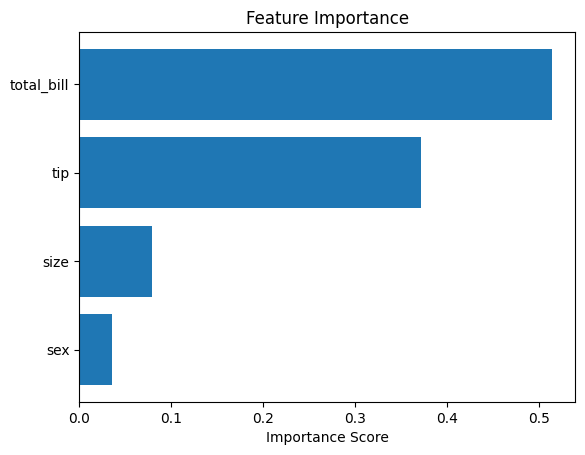

In [15]:
import matplotlib.pyplot as plt

importance = importance.sort_values(by="Importance")

plt.barh(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()
